## imports and setup

In [1]:
%env DJ_SUPPORT_FILEPATH_MANAGEMENT TRUE
# %load_ext autoreload
# %autoreload 2
%matplotlib inline

env: DJ_SUPPORT_FILEPATH_MANAGEMENT=TRUE


In [2]:
import hydra
from omegaconf import DictConfig, OmegaConf
import os
from time import sleep
import pickle


## configs

In [3]:
cwd = os.getcwd()
path_to_repo = "./GitRepos/simulation_closed_loop"
full_repo_path = os.path.join(cwd,path_to_repo)

config_path = os.path.join(path_to_repo, "config")
assert os.path.exists(config_path), f"Config path {config_path} does not exist."

# Initialize Hydra
hydra.initialize(config_path=config_path,version_base="1.3")

# Compose the configuration
cfg = hydra.compose(config_name="config")

import sys
sys.path.append(full_repo_path)

## get simulation loop components

In [4]:
from simulations.loop_components.dj_wrappers import OpenRetinaWrapper
# create preprocessor
openretinawrapper = OpenRetinaWrapper(
                username=cfg.DJ.username, # type: ignore
                home_directory=cfg.paths.home_directory, # type: ignore
                repo_directory=cfg.paths.repo_directory, # type: ignore
                dj_config_directory= cfg.paths.dj_config_directory, # type: ignore
                rgc_output_directory= cfg.paths.rgc_output_directory, # type: ignore
                userinfo= cfg.DJ.userinfo, # type: ignore
                # from overall configs 
                debug=cfg.debug, # type: ignore
                )

In [5]:
os.environ["DJ_SUPPORT_FILEPATH_MANAGEMENT"] = "TRUE"

In [6]:
openretinawrapper.load_config()
openretinawrapper.load_tables()

[2025-06-04 18:15:37,350][INFO]: Connecting ssuhai@172.25.240.200:3306
[2025-06-04 18:15:37,413][INFO]: Connected ssuhai@172.25.240.200:3306


schema_name: ageuler_ssuhai_closed_loop


In [14]:
openretinawrapper.tables['OpticDisk']().populate(processes=20, display_progress=True)
openretinawrapper.tables['OpticDisk']()


experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,od_fromfile File from which optic disc data was extracted,odx XCoord_um relative to the optic disk,ody YCoord_um relative to the optic disk,odz ZCoord_um relative to the optic disk
closedlooptest,2020-02-26,1,1,/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/updated_loop_data/20200226/1/20200226__left.ini,-1319.6,-467.6,13934.0


In [12]:
openretinawrapper.tables['RelativeFieldLocation']().populate(processes=20, display_progress=True)


RelativeFieldLocation: 100%|██████████| 1/1 [00:00<00:00, 67.08it/s]


{'success_count': 1, 'error_list': []}

In [13]:
openretinawrapper.tables['RelativeFieldLocation']()

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),relx XCoord_um relative to the optic disk,rely YCoord_um relative to the optic disk,relz ZCoord_um relative to the optic disk
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,770.84,-968.5,31.0


In [10]:
openretinawrapper.tables['RelativeRoiLocationWrtField']()

KeyError: 'RelativeRoiLocationWrtField'

## RF STA 

In [9]:
openretinawrapper.tables['DNoiseTraceParams']().add_default()

In [10]:
openretinawrapper.tables['DNoiseTraceParams']()

stim_name Unique string identifier,dnoise_params_id unique param set id,fit_kind,"fupsample_trace Multiplier of sampling frequency, using linear interpolation.","fupsample_stim Multiplier of sampling stimulus, using repeat.","lowpass_cutoff Cutoff frequency low pass filter, applied if larger 0.",pre_blur_sigma_s Gaussian blur applied after low pass filter.,post_blur_sigma_s Gaussian blur applied after all other steps.,ref_time Which time to use as reference.
noise,1,gradient,10,10,0.0,0.0,0.0,stim


In [24]:
openretinawrapper.tables['DNoiseTrace']().populate(processes=20, display_progress=True)

Processes: 100%|██████████| 107/107 [00:02<00:00, 35.82it/s]


{'success_count': 107, 'error_list': []}

In [13]:
openretinawrapper.tables['DNoiseTrace']()

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,dnoise_params_id unique param set id,trace Trace to fit,stim_idxs Stimulus frame indexes,noise_dt Time-step of time component,noise_t0 Time of first sample,"dt_rel_error Maximum relative error of dts, if too large, can have unwanted effects"
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,noise,control,1,1,1,=BLOB=,=BLOB=,0.0200195,23.8,0.109754
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,noise,control,2,1,1,=BLOB=,=BLOB=,0.0200195,23.8,0.109754
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,noise,control,3,1,1,=BLOB=,=BLOB=,0.0200195,23.8,0.109754
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,noise,control,4,1,1,=BLOB=,=BLOB=,0.0200195,23.8,0.109754
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,noise,control,5,1,1,=BLOB=,=BLOB=,0.0200195,23.8,0.109754
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,noise,control,6,1,1,=BLOB=,=BLOB=,0.0200195,23.8,0.109754
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,noise,control,7,1,1,=BLOB=,=BLOB=,0.0200195,23.8,0.109754
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,noise,control,8,1,1,=BLOB=,=BLOB=,0.0200195,23.8,0.109754
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,noise,control,9,1,1,=BLOB=,=BLOB=,0.0200195,23.8,0.109754
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,noise,control,10,1,1,=BLOB=,=BLOB=,0.0200195,23.8,0.109754


In [18]:
openretinawrapper.tables['STAParams']().add_default()
openretinawrapper.tables['STAParams']()

sta_params_id unique param set id,rf_method,filter_dur_s_past filter duration in seconds into the past,filter_dur_s_future filter duration in seconds into the future,"frac_train Fraction of data used for training in (0, 1].","frac_dev Fraction of data used for hyperparameter optimization in [0, 1).","frac_test Fraction of data used for testing [0, 1).",store_x Store x (stimulus) as data or shape (less storage)?,store_y Store y (response) as data or shape (less storage)?
1,sta,1.0,0.0,1.0,0.0,0.0,shape,shape


In [43]:
noise_dict = (openretinawrapper.tables['Stimulus']() & dict(stim_family="noise")).fetch(as_dict=True)[0]

In [45]:
noise_dict['stim_dict']

{'ntrigger_per_frame': 1,
 'pix_n_x': 20,
 'pix_n_y': 15,
 'pix_scale_x_um': 30,
 'pix_scale_y_um': 30,
 'offset_x_um': 0,
 'offset_y_um': 0}

In [47]:
openretinawrapper.tables.keys()

dict_keys(['UserInfo', 'Experiment', 'Field', 'Stimulus', 'RoiMask', 'Roi', 'Traces', 'Presentation', 'RawDataParams', 'PreprocessParams', 'PreprocessTraces', 'Snippets', 'Averages', 'ChirpQI', 'OsDsIndexes', 'ClassifierMethod', 'ClassifierTrainingData', 'Classifier', 'Baden16Traces', 'CelltypeAssignment', 'CascadeTraceParams', 'CascadeParams', 'CascadeTraces', 'CascadeSpikes', 'DNoiseTraceParams', 'DNoiseTrace', 'STAParams', 'STA', 'OpenRetinaHoeflingFormat'])

In [ ]:
openretinawrapper.tables['STA']().populate(processes=20, display_progress=True)
openretinawrapper.tables['STA']()

Processes: 100%|██████████| 107/107 [00:57<00:00,  1.87it/s]


experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,region region (e.g. LR or RR),cond1 condition (pharmacological or other),stim_name Unique string identifier,cond2 condition (pharmacological or other),roi_id integer id of each ROI,preprocess_id unique param set id,dnoise_params_id unique param set id,sta_params_id unique param set id,rf spatio-temporal receptive field,"rf_time time of RF, depends on dt and shift",dt Time step between frames,"shift Shift of stimulus relative to trace. If negative, prediction looks into future."
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,noise,control,1,1,1,1,=BLOB=,=BLOB=,0.0200195,0
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,noise,control,2,1,1,1,=BLOB=,=BLOB=,0.0200195,0
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,noise,control,3,1,1,1,=BLOB=,=BLOB=,0.0200195,0
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,noise,control,4,1,1,1,=BLOB=,=BLOB=,0.0200195,0
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,noise,control,5,1,1,1,=BLOB=,=BLOB=,0.0200195,0
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,noise,control,6,1,1,1,=BLOB=,=BLOB=,0.0200195,0
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,noise,control,7,1,1,1,=BLOB=,=BLOB=,0.0200195,0
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,noise,control,8,1,1,1,=BLOB=,=BLOB=,0.0200195,0
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,noise,control,9,1,1,1,=BLOB=,=BLOB=,0.0200195,0
closedlooptest,2020-02-26,1,1,GCL0,LR,iter0,noise,control,10,1,1,1,=BLOB=,=BLOB=,0.0200195,0


In [18]:
rf = openretinawrapper.tables['STA']().fetch('rf',as_dict = True)[0]

In [65]:
def get_rf_spatial_max_indices(rf: np.ndarray):
    """Get the spatial indices of the maximum value in the RF."""
    max_indices = np.unravel_index(np.argmax(rf), rf.shape)
    return max_indices[1:]

In [52]:

def convert_rf_indices_to_um(max_indices, openretinawrapper):
    """
    Note x is axis 0 (because goes from 0 to 20) and y is axis 1, in output of STA rf
    """
    max_x_idx,max_y_idx = max_indices
    
    # Get stimulus parameters
    stim_query = openretinawrapper.tables['Stimulus']() & {'stim_family': 'noise'}
    stim_dict = stim_query.fetch1('stim_dict')
    
    # Get pixel size and offset
    pixel_size_x_um = stim_dict.get('pix_scale_x_um', 30)
    pixel_size_y_um = stim_dict.get('pix_scale_y_um', 30)
    offset_x_um = stim_dict.get('offset_x_um', 0.0)
    offset_y_um = stim_dict.get('offset_y_um', 0.0)
    
    # Calculate position in microns
    x_um = max_x_idx * pixel_size_x_um + offset_x_um
    y_um = max_y_idx * pixel_size_y_um + offset_y_um
    
    return (x_um, y_um)


In [ ]:
openretinawrapper.tables['RelativeFieldLocation']().

['experimenter', 'date', 'exp_num', 'raw_id', 'field', 'region', 'cond1']

In [61]:
(openretinawrapper.tables['RelativeFieldLocation']() & {} ).fetch1("relx","rely")

(770.84, -968.5)

In [63]:
def get_rf_position_relative_to_optic_disk(rf_array, openretinawrapper, restriction = {}):
    """

    """
    # Step 1: Get maximum spatial indices
    max_indices = get_rf_spatial_max_indices(rf_array)
    
    # Step 2: Convert to microns relative to field center
    rf_x_field,rf_y_rel_field = convert_rf_indices_to_um(max_indices, openretinawrapper)
    
    # Step 3: Add field location to get position relative to optic disk
    field_loc_rel_optic_disk_um = (openretinawrapper.tables['RelativeFieldLocation']() & restriction).fetch1("relx","rely")
    
    # Return all results in a dictionary
    return rf_x_field + field_loc_rel_optic_disk_um[0], rf_y_rel_field + field_loc_rel_optic_disk_um[1]

In [42]:
import numpy as np
rf_array = rf['rf']
rf_abs_sum = (rf_array - rf_array.mean(axis = 0))
# Get indices of maximum
max_idx = np.unravel_index(np.argmax(rf_array), rf_abs_sum.shape)

In [66]:
get_rf_position_relative_to_optic_disk(rf_array, openretinawrapper, restriction = {})

(1130.8400000000001, -788.5)

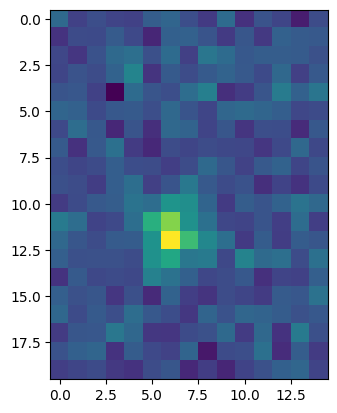

In [41]:
plt.imshow((rf_array - rf_array.mean(axis = 0))[44])

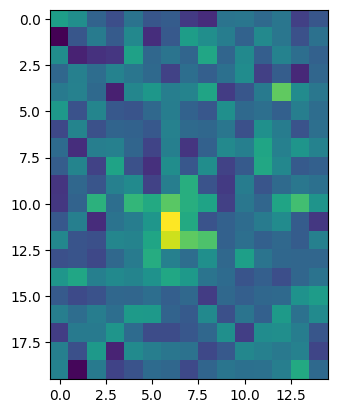

In [32]:
import matplotlib.pyplot as plt
plt.imshow(rf_array[49])

In [27]:
openretinawrapper.tables['STA']().delete()

[2025-06-04 16:40:43,351][INFO]: Deleting 107 rows from `ageuler_ssuhai_closed_loop`.`__s_t_a__data_set`
[2025-06-04 16:40:43,390][INFO]: Deleting 107 rows from `ageuler_ssuhai_closed_loop`.`__s_t_a`


[2025-06-04 16:40:45,789][INFO]: Deletes committed.


107

In [ ]:
from djimaging.utils.dj_utils import activate_schema
activate_schema(schema=openretinawrapper.schema, create_schema=True, create_tables=True)


In [ ]:
openretinawrapper('ClassifierMethod')()

In [ ]:
openretinawrapper.setup()

In [ ]:
openretinawrapper.schema.drop()

In [ ]:
import datajoint as dj


In [ ]:
dj.ERD(openretinawrapper.schema)

## Run the simulation

In [ ]:
iterations = 1 
all_traces = []
for iter in range(iterations):
    print(f"Iteration {iter+1}/{iterations}")
   
    # show stimulus 
    stimulator.stimulate()

    # Run the simulation
    recorder.record()
    
    # Process the data
    preprocessor.process_data(connect_and_activate=True)
    
    # sleep 
    sleep(1)
    





In [ ]:
stimulator.clean_up()
recorder.clean_up()
preprocessor.clean_up()
